# 08 — Explanations and statistics

**Input:** `models/dqn_seed0.zip`, `results/runs/*.parquet`
**Output:** the explanation modules, feature-importance and faithfulness results, and the statistical tests

In notebook 07 the DQN condition had a higher learning gain than both baselines, but its students answered 32.8% of questions correctly against 67.6% under the fixed curriculum. The agent gives more hints, and hinted items are recorded as incorrect. A teacher looking only at accuracy would think it was doing worse, which is why the recommendations need an explanation.

In [1]:
import importlib
import itertools
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

EATS = Path(r"C:\Users\vedac\Desktop\EATS")
sys.path.insert(0, str(EATS))
PROCESSED = EATS / "data" / "processed"
FIGURES = EATS / "results" / "figures"
RESULTS = EATS / "results"
MODELS = EATS / "models"

pd.set_option("display.width", 175)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})
BLUE, RED, GREY, GREEN, ORANGE = "#4C72B0", "#C44E52", "#7F7F7F", "#55A868", "#DD8452"

import joblib
from stable_baselines3 import DQN

from eats.simulator import interventions as iv
from eats.simulator.bkt import BKTParams
from eats.simulator.env import TutoringEnv
from eats.simulator.student import EmpiricalObservables

raw = pd.read_parquet(PROCESSED / "interactions_clean.parquet")
bundle = joblib.load(MODELS / "bkt_params.joblib")
PARAMS = {d["skill"]: BKTParams(**d) for d in bundle["params"]}
SKILLS = bundle["skills"]
cluster_model = joblib.load(MODELS / "error_clusters.joblib")

RT_STATS = {}
for s in SKILLS:
    v = raw.loc[raw["skill"] == s, "ms_first_response"]
    clip = np.percentile(v, cluster_model["clip_percentile"])
    lg = np.log1p(np.minimum(v, clip) / 1000)
    RT_STATS[s] = {"clip": float(clip), "mean": float(lg.mean()), "std": float(lg.std())}

observables = EmpiricalObservables(raw, SKILLS)
make_env = lambda seed=None: TutoringEnv(PARAMS, observables, cluster_model, RT_STATS, seed=seed)

model = DQN.load(MODELS / "dqn_seed0")
print(f"loaded models/dqn_seed0.zip  |  {iv.N_ACTIONS} actions, obs dim "
      f"{model.observation_space.shape[0]}")

loaded models/dqn_seed0.zip  |  5 actions, obs dim 7


## 8.1 What to explain

A DQN outputs five Q-values, but SHAP explains a single number. Options:

| Option | What it explains |
|---|---|
| Q(s, a\*) | why the chosen action scores highly, but not why it beat the others |
| **Q(s, a\*) − max other Q(s, a)** | why this action instead of the next best one |
| all five Q-values | complete, but hard to present |

I use the margin, because people usually ask "why this instead of that?" (Miller, 2019).

The chosen action a\* is fixed from the original state, so it doesn't change while features are perturbed.

In [2]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/xai/contrastive.py
"""The scalar function that SHAP explains: a contrastive decision margin."""

from __future__ import annotations

import numpy as np
import torch


def q_values(model, states):
    """Q-values for a batch of states. [n, n_actions]."""
    states = np.atleast_2d(np.asarray(states, dtype=np.float32))
    with torch.no_grad():
        t = torch.as_tensor(states, device=model.device)
        return model.policy.q_net(t).cpu().numpy()


def chosen_action(model, state):
    """The action the policy would take - the a* an explanation is about."""
    return int(np.argmax(q_values(model, state)[0]))


def margin(model, states, reference_action, runner_up=None):
    """Q(s, a*) - max_{a != a*} Q(s, a), for a FIXED reference action.

    Fixing a* matters. If the reference were recomputed for each perturbed state
    the explained function would change identity partway through, and the
    resulting attributions would not describe any single decision.

    Passing `runner_up` fixes the comparison action too, which gives a strictly
    pairwise "why this rather than that" contrast. Leaving it None compares
    against whichever alternative is best in each perturbed state - the more
    general "why this rather than anything else".
    """
    q = q_values(model, states)
    chosen = q[:, reference_action]
    if runner_up is not None:
        return chosen - q[:, runner_up]
    others = np.delete(q, reference_action, axis=1)
    return chosen - others.max(axis=1)


def decision_context(model, state):
    """Everything needed to describe one decision."""
    q = q_values(model, state)[0]
    order = np.argsort(q)[::-1]
    return {
        "q_values": q,
        "action": int(order[0]),
        "runner_up": int(order[1]),
        "margin": float(q[order[0]] - q[order[1]]),
    }

Overwriting C:/Users/vedac/Desktop/EATS/eats/xai/contrastive.py


## 8.2 Exact Shapley values

The proposal planned to use `KernelExplainer`, which estimates Shapley values by sampling. With only four features there are 2⁴ = 16 coalitions, so the exact values can be computed directly, and quickly.

The four one-hot `error_cluster` columns are treated as one feature, since exactly one of them is 1 at a time and a teacher needs one value for "error pattern".

In [3]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/xai/shapley.py
"""Exact Shapley values by full coalition enumeration.

With four conceptual features the complete set of 2^4 = 16 coalitions is small
enough to enumerate, so exact values are used instead of KernelExplainer's
sampling approximation.

A Shapley value is the average marginal contribution of a feature across every
possible ordering in which features could be added. The weighting below,
|S|!(n-|S|-1)!/n!, is exactly that average.
"""

from __future__ import annotations

import itertools
from math import factorial

import numpy as np

# Conceptual features, and the observation columns each occupies.
FEATURE_GROUPS = {
    "accuracy": [0],
    "response_time": [1],
    "hint_rate": [2],
    "error_cluster": [3, 4, 5, 6],   # one-hot: one unit, not four features
}
FEATURE_NAMES = list(FEATURE_GROUPS)

READABLE = {
    "accuracy": "quiz accuracy",
    "response_time": "response time",
    "hint_rate": "hint dependency",
    "error_cluster": "error pattern",
}


def _weights(n):
    """Shapley weight for a coalition of size s, over n features."""
    return {s: factorial(s) * factorial(n - s - 1) / factorial(n) for s in range(n)}


def exact_shapley(value_fn, state, background, groups=None):
    """Exact Shapley values for one state.

    value_fn : callable taking [m, d] states and returning [m] scalars
    state    : the observation to explain, shape [d]
    background : reference states, shape [b, d]. Absent features are replaced by
                 values drawn from these rows, so an attribution is always
                 relative to this reference population. A different background
                 gives different attributions.

    Returns (values dict, base_value, prediction).
    """
    groups = groups or FEATURE_GROUPS
    names = list(groups)
    n = len(names)
    state = np.asarray(state, dtype=np.float32)
    background = np.asarray(background, dtype=np.float32)
    b = len(background)
    weights = _weights(n)

    # Evaluate every coalition once: v(S) = mean over background of f(x_S).
    coalitions = [frozenset(c) for r in range(n + 1)
                  for c in itertools.combinations(range(n), r)]
    batch = np.empty((len(coalitions) * b, state.shape[0]), dtype=np.float32)
    for k, coalition in enumerate(coalitions):
        block = background.copy()                       # absent features: background
        for i in coalition:                             # present features: the instance
            for col in groups[names[i]]:
                block[:, col] = state[col]
        batch[k * b:(k + 1) * b] = block

    values = value_fn(batch).reshape(len(coalitions), b).mean(axis=1)
    v = dict(zip(coalitions, values))

    shapley = {}
    for i, name in enumerate(names):
        total = 0.0
        others = [j for j in range(n) if j != i]
        for r in range(n):
            for subset in itertools.combinations(others, r):
                S = frozenset(subset)
                total += weights[r] * (v[S | {i}] - v[S])
        shapley[name] = float(total)

    return shapley, float(v[frozenset()]), float(v[frozenset(range(n))])


def check_additivity(shapley, base_value, prediction, tol=1e-4):
    """Shapley values must sum to prediction - base_value (efficiency axiom).

    A check on the implementation: if the values don't sum, the coalition
    enumeration or the weighting is wrong.
    """
    total = sum(shapley.values())
    gap = abs(total - (prediction - base_value))
    return gap < tol, gap


Overwriting C:/Users/vedac/Desktop/EATS/eats/xai/shapley.py


In [4]:
from eats.xai import contrastive as ctr
from eats.xai import shapley as shp

importlib.reload(ctr); importlib.reload(shp)
from eats.xai.contrastive import decision_context, margin, q_values
from eats.xai.shapley import (FEATURE_GROUPS, FEATURE_NAMES, READABLE,
                              check_additivity, exact_shapley)

print("conceptual features:", FEATURE_NAMES)
print("observation columns:", {k: v for k, v in FEATURE_GROUPS.items()})

conceptual features: ['accuracy', 'response_time', 'hint_rate', 'error_cluster']
observation columns: {'accuracy': [0], 'response_time': [1], 'hint_rate': [2], 'error_cluster': [3, 4, 5, 6]}


### States to explain, and the background

Shapley values are relative to a background set. Here the background is a sample of 100 states the agent actually visits, so an explanation compares against a typical state.

In [5]:
def collect_states(policy, n_episodes=100, seed=7):
    """Run the policy and record every observation it acted on."""
    env = make_env(seed=seed)
    rows = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed * 1000 + ep)
        while True:
            a, _ = policy.predict(obs, deterministic=True)
            rows.append({"obs": obs.copy(), "action": int(a), "skill": info.get("skill")})
            obs, r, term, trunc, info = env.step(int(a))
            if term or trunc:
                break
    return rows


states = collect_states(model, n_episodes=100, seed=7)
X = np.stack([r["obs"] for r in states])
actions = np.array([r["action"] for r in states])

rng = np.random.default_rng(0)
BACKGROUND_N = 100
background = X[rng.choice(len(X), BACKGROUND_N, replace=False)]

print(f"{len(X):,} states collected | background = {BACKGROUND_N} samples")
print(f"action mix: " + ", ".join(
    f"{iv.ACTIONS[a]}={np.mean(actions==a):.2f}" for a in range(iv.N_ACTIONS)))

2,000 states collected | background = 100 samples
action mix: lower_difficulty=0.03, maintain_difficulty=0.26, raise_difficulty=0.16, provide_hint=0.34, recommend_revision=0.21


### Additivity check

Shapley values should add up to the prediction minus the base value. This checks the coalition enumeration and weights.

In [6]:
gaps = []
for idx in range(200):
    s = X[idx]
    ctx = decision_context(model, s)
    f = lambda batch, a=ctx["action"]: margin(model, batch, a)
    sv, base, pred = exact_shapley(f, s, background)
    ok, gap = check_additivity(sv, base, pred)
    gaps.append(gap)

gaps = np.array(gaps)
print(f"additivity check over 200 explanations")
print(f"  max |sum(shapley) - (prediction - base)| = {gaps.max():.2e}")
print(f"  mean = {gaps.mean():.2e}")
print(f"  all within 1e-4: {bool((gaps < 1e-4).all())}")

additivity check over 200 explanations
  max |sum(shapley) - (prediction - base)| = 3.13e-09
  mean = 7.14e-10
  all within 1e-4: True


## 8.3 Latency

The proposal targeted explanations within 100 ms. Enumerating 16 coalitions over a 100-state background is 1,600 rows in one batched forward pass.

In [7]:
def explain(state, model=model, background=background):
    ctx = decision_context(model, state)
    f = lambda batch, a=ctx["action"]: margin(model, batch, a)
    sv, base, pred = exact_shapley(f, state, background)
    return sv, base, pred, ctx


t0 = time.perf_counter()
for idx in range(200):
    explain(X[idx])
per = (time.perf_counter() - t0) / 200 * 1000
print(f"exact Shapley: {per:.2f} ms per explanation")
print(f"proposal target: 100 ms   ->  {'MET' if per < 100 else 'NOT MET'}")
print(f"proposal Risk 4 threshold: 500 ms  ->  {'no risk' if per < 500 else 'RISK'}")
print(f"\n16 coalitions x {BACKGROUND_N} background rows = "
      f"{16*BACKGROUND_N:,} forward passes, batched")

exact Shapley: 0.38 ms per explanation
proposal target: 100 ms   ->  MET
proposal Risk 4 threshold: 500 ms  ->  no risk

16 coalitions x 100 background rows = 1,600 forward passes, batched


### Comparison with `shap.KernelExplainer`

KernelExplainer treats the seven columns separately, so its four cluster values are added together before comparing.

In [8]:
try:
    import shap

    idx = 0
    ctx = decision_context(model, X[idx])
    f = lambda batch, a=ctx["action"]: margin(model, batch, a)

    ke = shap.KernelExplainer(f, background)
    ks = ke.shap_values(X[idx], nsamples=512, silent=True)

    mine, _, _ = exact_shapley(f, X[idx], background)
    grouped = {
        "accuracy": ks[0], "response_time": ks[1], "hint_rate": ks[2],
        "error_cluster": float(np.sum(ks[3:7])),
    }
    cmp = pd.DataFrame({"exact (ours)": mine, "KernelExplainer": grouped})
    cmp["difference"] = cmp["exact (ours)"] - cmp["KernelExplainer"]
    print(cmp.round(5).to_string())
    print(f"\nmax absolute difference: {cmp['difference'].abs().max():.5f}")
    print("Small differences are expected - KernelExplainer samples coalitions,")
    print("ours enumerates all of them. Ours is the exact value.")
except Exception as e:
    print(f"KernelExplainer comparison skipped: {type(e).__name__}: {e}")

C:\Users\vedac\Desktop\EATS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


               exact (ours)  KernelExplainer  difference
accuracy            0.00694          0.00386     0.00307
response_time      -0.00065         -0.00052    -0.00013
hint_rate          -0.01687         -0.01847     0.00159
error_cluster       0.02396          0.02850    -0.00454

max absolute difference: 0.00454
Small differences are expected - KernelExplainer samples coalitions,
ours enumerates all of them. Ours is the exact value.


## 8.4 Turning values into sentences

Raw SHAP values such as −0.31 don't mean much to a teacher, so the templates rank the features and describe them in words ("the main reason", "also contributing"). The numbers are kept in a separate technical view.

The sentence also names the action that was not chosen.

Note: the templates rank features by the size of their Shapley value and don't use the sign, so the wording doesn't say which way a feature pushed the decision.

In [9]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/xai/templates.py
"""Turn Shapley values into a short sentence for a teacher."""

from __future__ import annotations

import numpy as np

from eats.simulator import interventions as iv
from eats.xai.shapley import FEATURE_GROUPS, READABLE

# Cluster names from the notebook 04 profiles, ordered by severity.
CLUSTER_NAMES = {
    0: "on track",
    1: "occasional difficulty",
    2: "unproductive persistence",
    3: "systematic misconception",
}

ACTION_PHRASES = {
    "lower_difficulty": "easier material",
    "maintain_difficulty": "staying at this level",
    "raise_difficulty": "harder material",
    "provide_hint": "a hint",
    "recommend_revision": "revision of the earlier topic",
}

# Words instead of raw values, which are hard to interpret without context.
def _emphasis(rank):
    return ["The main reason is", "This is reinforced by", "A smaller factor is"][min(rank, 2)]


def describe_feature(name, state):
    """Plain-language description of one feature's current value."""
    if name == "accuracy":
        return f"recent accuracy of {state[0]:.0%}"
    if name == "response_time":
        pace = "slower" if state[1] > 0.55 else "faster" if state[1] < 0.45 else "typical"
        return f"a {pace} working pace" if pace != "typical" else "a typical working pace"
    if name == "hint_rate":
        return f"help being sought on {state[2]:.0%} of the problems answered wrongly"
    if name == "error_cluster":
        cluster = int(np.argmax(state[3:7]))
        return f"an error pattern of {CLUSTER_NAMES.get(cluster, cluster)}"
    return name


def explain_in_words(shapley, state, action, runner_up, top_k=2):
    """One contrastive sentence, plus supporting clauses.

    Contrastive ("why this rather than that"), following Miller (2019).

    Features are ranked by the absolute size of their Shapley value. The sign is
    not used, so the sentence doesn't say which way a feature pushed the decision.
    """
    ranked = sorted(shapley.items(), key=lambda kv: abs(kv[1]), reverse=True)
    ranked = [(k, v) for k, v in ranked if abs(v) > 1e-6][:top_k]

    lead = (f"{iv.ACTIONS[action].replace('_', ' ').capitalize()} was recommended "
            f"rather than {ACTION_PHRASES.get(iv.ACTIONS[runner_up], 'the alternative')}")
    if not ranked:
        return lead + ", though no single factor stood out."

    parts = [f"{lead}. {_emphasis(0)} {describe_feature(ranked[0][0], state)}."]
    for rank, (name, _) in enumerate(ranked[1:], start=1):
        parts.append(f"{_emphasis(rank)} {describe_feature(name, state)}.")
    return " ".join(parts)


def technical_view(shapley, base_value, prediction, action, runner_up):
    """The raw numbers, for analysis."""
    rows = sorted(shapley.items(), key=lambda kv: abs(kv[1]), reverse=True)
    lines = [f"action={iv.ACTIONS[action]}  vs  {iv.ACTIONS[runner_up]}",
             f"margin={prediction:.4f}  base={base_value:.4f}"]
    lines += [f"  {READABLE[k]:<18} {v:+.4f}" for k, v in rows]
    lines.append(f"  {'sum':<18} {sum(shapley.values()):+.4f}")
    return "\n".join(lines)


Overwriting C:/Users/vedac/Desktop/EATS/eats/xai/templates.py


In [10]:
from eats.xai import templates as tpl

importlib.reload(tpl)
from eats.xai.templates import CLUSTER_NAMES, explain_in_words, technical_view

rng2 = np.random.default_rng(3)
for idx in rng2.choice(len(X), 6, replace=False):
    sv, base, pred, ctx = explain(X[idx])
    print(explain_in_words(sv, X[idx], ctx["action"], ctx["runner_up"]))
    print()

Provide hint was recommended rather than harder material. The main reason is recent accuracy of 0%. This is reinforced by help being sought on 90% of the problems answered wrongly.

Maintain difficulty was recommended rather than harder material. The main reason is recent accuracy of 100%. This is reinforced by help being sought on 0% of the problems answered wrongly.

Recommend revision was recommended rather than harder material. The main reason is help being sought on 100% of the problems answered wrongly. This is reinforced by recent accuracy of 20%.

Recommend revision was recommended rather than a hint. The main reason is help being sought on 100% of the problems answered wrongly. This is reinforced by recent accuracy of 50%.

Maintain difficulty was recommended rather than revision of the earlier topic. The main reason is recent accuracy of 80%. This is reinforced by help being sought on 50% of the problems answered wrongly.

Recommend revision was recommended rather than a hint

In [11]:
# Numeric view (not shown on the dashboard).
idx = int(rng2.integers(len(X)))
sv, base, pred, ctx = explain(X[idx])
print(technical_view(sv, base, pred, ctx["action"], ctx["runner_up"]))

action=maintain_difficulty  vs  lower_difficulty
margin=0.0001  base=-0.0140
  quiz accuracy      +0.0223
  hint dependency    -0.0220
  error pattern      +0.0216
  response time      -0.0078
  sum                +0.0141


## 8.5 Which features drive the decisions? (RQ3)

Global importance is the mean absolute Shapley value over many decisions, with bootstrap confidence intervals. The per-action breakdown shows whether different actions depend on different features.

In [12]:
N_EXPLAIN = 600
rows = []
t0 = time.perf_counter()
for i in range(min(N_EXPLAIN, len(X))):
    sv, base, pred, ctx = explain(X[i])
    rows.append({"idx": i, "action": ctx["action"],
                 "action_name": iv.ACTIONS[ctx["action"]],
                 "runner_up": ctx["runner_up"], "margin": ctx["margin"], **sv})
expl = pd.DataFrame(rows)
expl.to_csv(RESULTS / "shap_explanations.csv", index=False)
print(f"{len(expl)} explanations in {time.perf_counter()-t0:.1f}s")

imp = expl[FEATURE_NAMES].abs().mean().sort_values(ascending=False)
boot = {}
rb = np.random.default_rng(0)
for f in FEATURE_NAMES:
    vals = expl[f].abs().to_numpy()
    means = [rb.choice(vals, len(vals), replace=True).mean() for _ in range(2000)]
    boot[f] = np.percentile(means, [2.5, 97.5])

summary = pd.DataFrame({
    "mean |SHAP|": imp,
    "ci_low": [boot[f][0] for f in imp.index],
    "ci_high": [boot[f][1] for f in imp.index],
    "share": (imp / imp.sum()),
})
summary.round(4)

600 explanations in 0.3s


,mean |SHAP|,ci_low,ci_high,share
accuracy,0.0153,0.0146,0.0160,0.4522
hint_rate,0.0109,0.0104,0.0115,0.3234
error_cluster,0.0062,0.0057,0.0068,0.1834
response_time,0.0014,0.0012,0.0016,0.0410


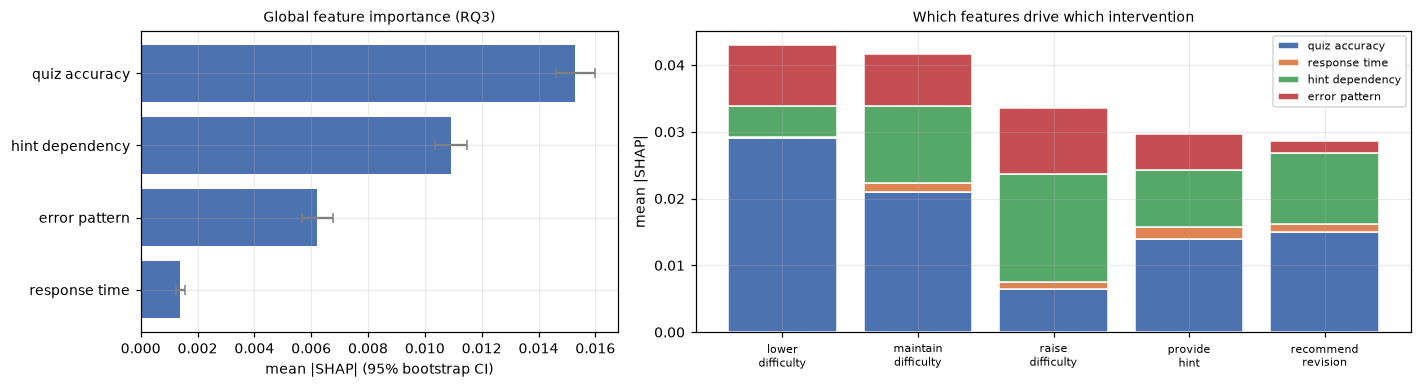

,accuracy,response_time,hint_rate,error_cluster
action_name,,,,
lower_difficulty,0.0291,0.0001,0.0046,0.0091
maintain_difficulty,0.0210,0.0014,0.0115,0.0078
raise_difficulty,0.0064,0.0012,0.0162,0.0098
provide_hint,0.0139,0.0019,0.0085,0.0055
recommend_revision,0.0150,0.0011,0.0108,0.0017


In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6),
                             gridspec_kw={"width_ratios": [1, 1.5]})

y = np.arange(len(imp))
a1.barh(y, imp.values, color=BLUE,
        xerr=[imp.values - summary["ci_low"], summary["ci_high"] - imp.values],
        error_kw={"ecolor": GREY, "capsize": 3})
a1.set_yticks(y); a1.set_yticklabels([READABLE[f] for f in imp.index])
a1.invert_yaxis(); a1.set_xlabel("mean |SHAP| (95% bootstrap CI)")
a1.set_title("Global feature importance (RQ3)", fontsize=9)

per_action = (expl.groupby("action_name")[FEATURE_NAMES]
              .apply(lambda g: g.abs().mean()))
per_action = per_action.reindex([a for a in iv.ACTIONS if a in per_action.index])
bottom = np.zeros(len(per_action))
for f, colour in zip(FEATURE_NAMES, [BLUE, ORANGE, GREEN, RED]):
    a2.bar(range(len(per_action)), per_action[f], bottom=bottom,
           label=READABLE[f], color=colour, edgecolor="white")
    bottom += per_action[f].to_numpy()
a2.set_xticks(range(len(per_action)))
a2.set_xticklabels([a.replace("_", "\n") for a in per_action.index], fontsize=7)
a2.set_ylabel("mean |SHAP|"); a2.legend(fontsize=7)
a2.set_title("Which features drive which intervention", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES / "fig_5_2_shap_importance.png", bbox_inches="tight")
plt.show()

per_action.round(4)

## 8.6 Are the explanations faithful? (RQ2)

If an explanation reflects the model, removing the feature it ranks most important should change the decision more often than removing the one it ranks least important.

A feature is "removed" by replacing its columns with values from the background, the same way the Shapley calculation does. For the cluster this draws a real cluster, not a fractional mix.

In [14]:
def flip_rate(feature, n_draws=10, n_states=400, seed=0):
    """How often does replacing this feature change the chosen action?"""
    r = np.random.default_rng(seed)
    cols = FEATURE_GROUPS[feature]
    flips = []
    for i in range(min(n_states, len(expl))):
        s = X[int(expl["idx"].iloc[i])]
        original = int(expl["action"].iloc[i])
        changed = 0
        for _ in range(n_draws):
            alt = s.copy()
            donor = background[r.integers(len(background))]
            alt[cols] = donor[cols]
            if int(np.argmax(q_values(model, alt)[0])) != original:
                changed += 1
        flips.append(changed / n_draws)
    return float(np.mean(flips))


ranked_per_state = expl[FEATURE_NAMES].abs().rank(axis=1, ascending=False)
top_feature = ranked_per_state.idxmin(axis=1)
bottom_feature = ranked_per_state.idxmax(axis=1)

print("feature ranked MOST important, by frequency:")
print(top_feature.value_counts(normalize=True).round(3).to_string())
print("\nfeature ranked LEAST important, by frequency:")
print(bottom_feature.value_counts(normalize=True).round(3).to_string())

feature ranked MOST important, by frequency:
accuracy         0.650
hint_rate        0.258
error_cluster    0.090
response_time    0.002

feature ranked LEAST important, by frequency:
response_time    0.822
error_cluster    0.127
hint_rate        0.042
accuracy         0.010


In [15]:
def flip_rate_by_rank(which="top", n_draws=10, n_states=400, seed=0):
    """Flip rate when removing each state's OWN top- (or bottom-) ranked feature."""
    r = np.random.default_rng(seed)
    chooser = top_feature if which == "top" else bottom_feature
    flips = []
    for i in range(min(n_states, len(expl))):
        s = X[int(expl["idx"].iloc[i])]
        original = int(expl["action"].iloc[i])
        cols = FEATURE_GROUPS[chooser.iloc[i]]
        changed = 0
        for _ in range(n_draws):
            alt = s.copy()
            donor = background[r.integers(len(background))]
            alt[cols] = donor[cols]
            if int(np.argmax(q_values(model, alt)[0])) != original:
                changed += 1
        flips.append(changed / n_draws)
    return np.array(flips)


t0 = time.perf_counter()
top_flips = flip_rate_by_rank("top", seed=1)
bottom_flips = flip_rate_by_rank("bottom", seed=1)
per_feature = {f: flip_rate(f, seed=2) for f in FEATURE_NAMES}
print(f"computed in {time.perf_counter()-t0:.0f}s\n")

from scipy import stats as sps
stat, pval = sps.wilcoxon(top_flips, bottom_flips)
print(f"removing the TOP-ranked feature    flips the decision {top_flips.mean():.1%} of the time")
print(f"removing the BOTTOM-ranked feature flips the decision {bottom_flips.mean():.1%} of the time")
print(f"difference: {top_flips.mean()-bottom_flips.mean():+.1%}")
print(f"Wilcoxon signed-rank: W={stat:.0f}, p={pval:.2e}")
print()
if top_flips.mean() > bottom_flips.mean():
    print("The explanations are FAITHFUL: the feature SHAP identifies as most")
    print("important is the one whose removal most often changes the decision.")
else:
    print("NOT faithful - the ranking does not predict decision sensitivity.")
    print("Report this. An unfaithful explanation is worse than none.")

computed in 2s

removing the TOP-ranked feature    flips the decision 59.9% of the time
removing the BOTTOM-ranked feature flips the decision 12.8% of the time
difference: +47.1%
Wilcoxon signed-rank: W=2018, p=3.03e-57

The explanations are FAITHFUL: the feature SHAP identifies as most
important is the one whose removal most often changes the decision.


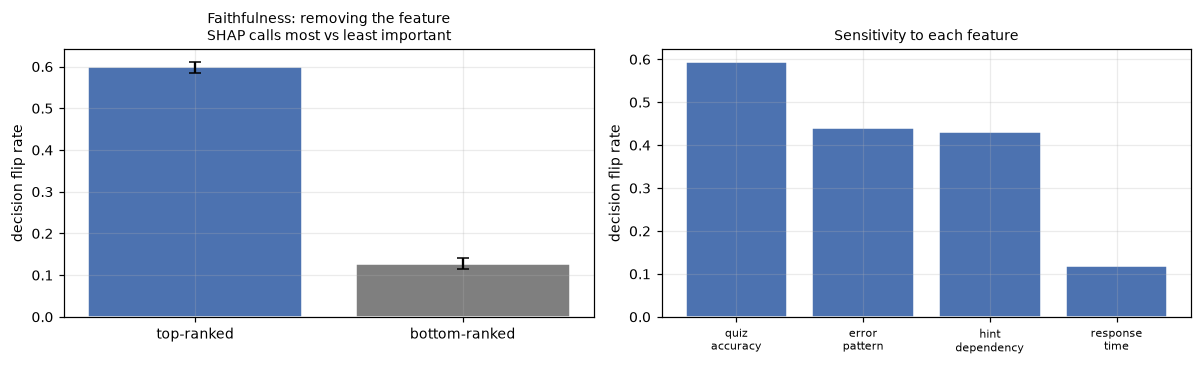

In [16]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))

a1.bar(["top-ranked", "bottom-ranked"], [top_flips.mean(), bottom_flips.mean()],
       color=[BLUE, GREY], edgecolor="white",
       yerr=[top_flips.std()/np.sqrt(len(top_flips)),
             bottom_flips.std()/np.sqrt(len(bottom_flips))],
       error_kw={"ecolor": "black", "capsize": 4})
a1.set_ylabel("decision flip rate")
a1.set_title("Faithfulness: removing the feature\nSHAP calls most vs least important", fontsize=9)

pf = pd.Series(per_feature).sort_values(ascending=False)
a2.bar(range(len(pf)), pf.values, color=BLUE, edgecolor="white")
a2.set_xticks(range(len(pf)))
a2.set_xticklabels([READABLE[f].replace(" ", "\n") for f in pf.index], fontsize=7)
a2.set_ylabel("decision flip rate")
a2.set_title("Sensitivity to each feature", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES / "fig_5_3_faithfulness.png", bbox_inches="tight")
plt.show()

### Explanations for manual review

Twenty explanations are printed below, with a blank scoring sheet (`results/rubric_blank.csv`) for rating clarity, correctness and usefulness. The reviewer questionnaire was run separately.

In [17]:
rubric = []
rs = np.random.default_rng(11)
for k, idx in enumerate(rs.choice(len(X), 20, replace=False), start=1):
    sv, base, pred, ctx = explain(X[idx])
    text = explain_in_words(sv, X[idx], ctx["action"], ctx["runner_up"])
    s = X[idx]
    print(f"[{k:>2}] {text}")
    print(f"     state: accuracy={s[0]:.2f} pace={s[1]:.2f} hint_rate={s[2]:.2f} "
          f"cluster={int(np.argmax(s[3:7]))} ({CLUSTER_NAMES[int(np.argmax(s[3:7]))]})")
    print()
    rubric.append({"n": k, "explanation": text,
                   "accuracy": float(s[0]), "hint_rate": float(s[2]),
                   "cluster": int(np.argmax(s[3:7])),
                   "clarity": "", "correctness": "", "actionability": ""})

pd.DataFrame(rubric).to_csv(RESULTS / "rubric_blank.csv", index=False)
print(f"blank scoring sheet: {RESULTS / 'rubric_blank.csv'}")

[ 1] Provide hint was recommended rather than staying at this level. The main reason is help being sought on 0% of the problems answered wrongly. This is reinforced by recent accuracy of 60%.
     state: accuracy=0.60 pace=0.65 hint_rate=0.00 cluster=1 (occasional difficulty)

[ 2] Recommend revision was recommended rather than a hint. The main reason is recent accuracy of 67%. This is reinforced by an error pattern of occasional difficulty.
     state: accuracy=0.67 pace=0.39 hint_rate=0.50 cluster=1 (occasional difficulty)

[ 3] Raise difficulty was recommended rather than revision of the earlier topic. The main reason is help being sought on 100% of the problems answered wrongly. This is reinforced by a faster working pace.
     state: accuracy=0.20 pace=0.05 hint_rate=1.00 cluster=3 (systematic misconception)

[ 4] Provide hint was recommended rather than easier material. The main reason is recent accuracy of 0%. This is reinforced by a faster working pace.
     state: accuracy=0.0

## 8.7 Statistical tests (RQ1 and RQ4)

There are 6,000 evaluation episodes, but episodes from the same seed come from one trained policy, so testing at episode level would treat correlated results as independent. Tests are run on seed-level values instead: n = 10 per condition.

With n = 10, normality can't really be checked, so Shapiro–Wilk is reported but the main tests are non-parametric: Kruskal–Wallis across the three conditions and Mann–Whitney U for pairs. Effect sizes are reported alongside.

In [18]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/eval/stats.py
"""Statistical comparison of the three conditions.

The unit of analysis is the seed. Episodes within a seed share a trained policy
and are not independent observations of the method.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
from scipy import stats


def seed_level(episodes, metrics):
    """Collapse episodes to one row per (condition, seed)."""
    return episodes.groupby(["condition", "seed"])[metrics].mean().reset_index()


def cohens_d(a, b):
    """Standardised mean difference, pooled SD."""
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt((a.std(ddof=1) ** 2 + b.std(ddof=1) ** 2) / 2)
    return float((a.mean() - b.mean()) / pooled) if pooled > 0 else 0.0


def bootstrap_ci(a, b, n=5000, seed=0):
    """Percentile CI for the difference in means."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    diffs = [rng.choice(a, len(a), True).mean() - rng.choice(b, len(b), True).mean()
             for _ in range(n)]
    return tuple(np.percentile(diffs, [2.5, 97.5]))


def normality(by_seed, metric, conditions):
    """Shapiro-Wilk per condition. Reported, not relied upon: with n=10 a
    non-significant result is weak evidence of normality, not proof of it."""
    out = []
    for c in conditions:
        v = by_seed.loc[by_seed["condition"] == c, metric]
        w, p = stats.shapiro(v)
        out.append({"condition": c, "W": w, "p": p, "normal_at_0.05": p > 0.05})
    return pd.DataFrame(out)


def compare(by_seed, metric, conditions, reference="dqn"):
    """Kruskal-Wallis across conditions, then Mann-Whitney against `reference`."""
    groups = [by_seed.loc[by_seed["condition"] == c, metric].to_numpy() for c in conditions]
    H, p_kw = stats.kruskal(*groups)

    ref = by_seed.loc[by_seed["condition"] == reference, metric].to_numpy()
    rows = []
    for c in conditions:
        if c == reference:
            continue
        other = by_seed.loc[by_seed["condition"] == c, metric].to_numpy()
        U, p = stats.mannwhitneyu(ref, other, alternative="two-sided")
        lo, hi = bootstrap_ci(ref, other)
        rows.append({
            "metric": metric,
            "comparison": f"{reference} vs {c}",
            "mean_ref": ref.mean(),
            "mean_other": other.mean(),
            "difference": ref.mean() - other.mean(),
            "ci_low": lo,
            "ci_high": hi,
            "cohens_d": cohens_d(ref, other),
            "U": U,
            "p": p,
            "significant_at_0.05": p < 0.05,
        })
    return {"H": H, "p_kruskal": p_kw, "n_per_group": len(ref),
            "pairwise": pd.DataFrame(rows)}


def interpret_d(d):
    """Cohen's conventional labels (a rough guide)."""
    a = abs(d)
    return "negligible" if a < 0.2 else "small" if a < 0.5 else "medium" if a < 0.8 else "large"


Overwriting C:/Users/vedac/Desktop/EATS/eats/eval/stats.py


In [19]:
from eats.eval import stats as st_mod

importlib.reload(st_mod)
from eats.eval.stats import compare, interpret_d, normality, seed_level

episodes = pd.read_parquet(RESULTS / "runs" / "episodes.parquet")
METRICS = ["learning_gain", "accuracy_slope", "hint_reduction", "return",
           "observed_accuracy", "final_mastery", "hint_rate"]
CONDITIONS = ["static", "rule_based", "dqn"]

by_seed = seed_level(episodes, METRICS)
by_seed.to_csv(RESULTS / "runs" / "seed_level.csv", index=False)

print(f"episodes: {len(episodes):,}   seed-level rows: {len(by_seed)} "
      f"({by_seed.seed.nunique()} seeds x {len(CONDITIONS)} conditions)")
print(f"\nTesting at n={by_seed.seed.nunique()} per condition, NOT n={len(episodes)//3}.")
by_seed.groupby("condition")[METRICS].agg(["mean", "std"]).round(4)

episodes: 6,000   seed-level rows: 30 (10 seeds x 3 conditions)

Testing at n=10 per condition, NOT n=2000.


learning_gain         accuracy_slope         hint_reduction          return         observed_accuracy         final_mastery         hint_rate        
                    mean     std           mean     std           mean     std    mean     std              mean     std          mean     std      mean     std
condition                                                                                                                                                       
dqn               0.8787  0.0432         0.0109  0.0113         0.2318  0.2674  0.1675  0.1013            0.3283  0.2464        0.9642  0.0114    0.6091  0.2923
rule_based        0.6529  0.0539         0.0064  0.0021         0.0693  0.0320  0.1921  0.0233            0.6052  0.0070        0.8799  0.0204    0.2838  0.0058
static            0.7864  0.0587         0.0064  0.0015         0.0568  0.0250  0.2787  0.0250            0.6761  0.0101        0.9315  0.0170    0.1852  0.0081

In [20]:
print("=== Shapiro-Wilk normality (reported, not relied upon) ===")
for m in ["learning_gain", "accuracy_slope", "hint_reduction", "return"]:
    n = normality(by_seed, m, CONDITIONS)
    flag = "" if n["normal_at_0.05"].all() else "   <- not normal in at least one group"
    print(f"\n{m}{flag}")
    print(n.round(4).to_string(index=False))

=== Shapiro-Wilk normality (reported, not relied upon) ===

learning_gain
 condition      W      p  normal_at_0.05
    static 0.9598 0.7841            True
rule_based 0.9776 0.9513            True
       dqn 0.9613 0.8003            True

accuracy_slope
 condition      W      p  normal_at_0.05
    static 0.9440 0.5982            True
rule_based 0.9242 0.3930            True
       dqn 0.8568 0.0700            True

hint_reduction   <- not normal in at least one group
 condition      W      p  normal_at_0.05
    static 0.9829 0.9790            True
rule_based 0.9693 0.8840            True
       dqn 0.7948 0.0125           False

return
 condition      W      p  normal_at_0.05
    static 0.9651 0.8425            True
rule_based 0.9747 0.9307            True
       dqn 0.8864 0.1545            True


In [21]:
results = {}
blocks = []
for m in ["learning_gain", "accuracy_slope", "hint_reduction", "return"]:
    r = compare(by_seed, m, CONDITIONS, reference="dqn")
    results[m] = r
    pw = r["pairwise"].copy()
    pw["kruskal_H"] = r["H"]
    pw["kruskal_p"] = r["p_kruskal"]
    pw["effect"] = pw["cohens_d"].map(interpret_d)
    blocks.append(pw)

table = pd.concat(blocks, ignore_index=True)
table.to_csv(RESULTS / "runs" / "statistical_tests.csv", index=False)

cols = ["metric", "comparison", "mean_ref", "mean_other", "difference",
        "ci_low", "ci_high", "cohens_d", "effect", "p", "significant_at_0.05"]
table[cols].round(4)

,metric,comparison,mean_ref,mean_other,difference,ci_low,ci_high,cohens_d,effect,p,significant_at_0.05
0,learning_gain,dqn vs static,0.8787,0.7864,0.0922,0.0497,0.1345,1.7895,large,0.0017,True
1,learning_gain,dqn vs rule_based,0.8787,0.6529,0.2258,0.1853,0.2661,4.6234,large,0.0002,True
2,accuracy_slope,dqn vs static,0.0109,0.0064,0.0045,-0.0018,0.0116,0.5583,medium,0.5708,False
3,accuracy_slope,dqn vs rule_based,0.0109,0.0064,0.0045,-0.0018,0.0116,0.5553,medium,0.6232,False
4,hint_reduction,dqn vs static,0.2318,0.0568,0.1750,0.0263,0.3369,0.9217,large,0.3845,False
5,hint_reduction,dqn vs rule_based,0.2318,0.0693,0.1625,0.0137,0.3258,0.8535,large,0.5706,False
6,return,dqn vs static,0.1675,0.2787,-0.1112,-0.1751,-0.0524,-1.5066,large,0.0036,True
7,return,dqn vs rule_based,0.1675,0.1921,-0.0246,-0.0874,0.0336,-0.3347,small,0.8501,False


In [22]:
print("=== Kruskal-Wallis across all three conditions ===")
for m, r in results.items():
    verdict = "significant" if r["p_kruskal"] < 0.05 else "NOT significant"
    print(f"  {m:<18} H={r['H']:>6.3f}  p={r['p_kruskal']:.4f}   {verdict}")

=== Kruskal-Wallis across all three conditions ===
  learning_gain      H=22.578  p=0.0000   significant
  accuracy_slope     H= 0.545  p=0.7617   NOT significant
  hint_reduction     H= 1.280  p=0.5272   NOT significant
  return             H=15.517  p=0.0004   significant


## 8.8 Summary of results

The results are mixed: some differences are significant and some aren't.

In [23]:
def verdict(metric, other="static"):
    row = table[(table["metric"] == metric) &
                (table["comparison"] == f"dqn vs {other}")].iloc[0]
    direction = "higher" if row["difference"] > 0 else "lower"
    sig = "significant" if row["p"] < 0.05 else "not significant"
    return (f"{row['difference']:+.4f} ({direction}), d={row['cohens_d']:+.2f} "
            f"({interpret_d(row['cohens_d'])}), p={row['p']:.4f} - {sig}")


print("RQ1  Does the DQN select more effective interventions than the baselines?")
print(f"     Learning Gain     vs static     : {verdict('learning_gain','static')}")
print(f"     Learning Gain     vs rule_based : {verdict('learning_gain','rule_based')}")
print(f"     Accuracy slope    vs static     : {verdict('accuracy_slope','static')}")
print()
print("RQ2  Are the explanations faithful, and readable?")
print(f"     Faithfulness: top-ranked feature flips the decision {top_flips.mean():.1%}")
print(f"                   bottom-ranked flips it {bottom_flips.mean():.1%}, p={pval:.2e}")
print(f"     Latency: {per:.1f} ms per explanation (target 100 ms)")
print("     Readability: author self-assessment, rubric_blank.csv")
print()
print("RQ3  Which features drive the decisions?")
for f, v in imp.items():
    print(f"     {READABLE[f]:<18} mean |SHAP| = {v:.4f}  ({v/imp.sum():.1%})")
print()
print("RQ4  Does hint dependency fall over the evaluation period?")
print(f"     Hint reduction    vs static     : {verdict('hint_reduction','static')}")
print(f"     Hint reduction    vs rule_based : {verdict('hint_reduction','rule_based')}")

RQ1  Does the DQN select more effective interventions than the baselines?
     Learning Gain     vs static     : +0.0922 (higher), d=+1.79 (large), p=0.0017 - significant
     Learning Gain     vs rule_based : +0.2258 (higher), d=+4.62 (large), p=0.0002 - significant
     Accuracy slope    vs static     : +0.0045 (higher), d=+0.56 (medium), p=0.5708 - not significant

RQ2  Are the explanations faithful, and readable?
     Faithfulness: top-ranked feature flips the decision 59.9%
                   bottom-ranked flips it 12.8%, p=3.03e-57
     Latency: 0.4 ms per explanation (target 100 ms)
     Readability: author self-assessment, rubric_blank.csv

RQ3  Which features drive the decisions?
     quiz accuracy      mean |SHAP| = 0.0153  (45.2%)
     hint dependency    mean |SHAP| = 0.0109  (32.3%)
     error pattern      mean |SHAP| = 0.0062  (18.3%)
     response time      mean |SHAP| = 0.0014  (4.1%)

RQ4  Does hint dependency fall over the evaluation period?
     Hint reduction    vs s

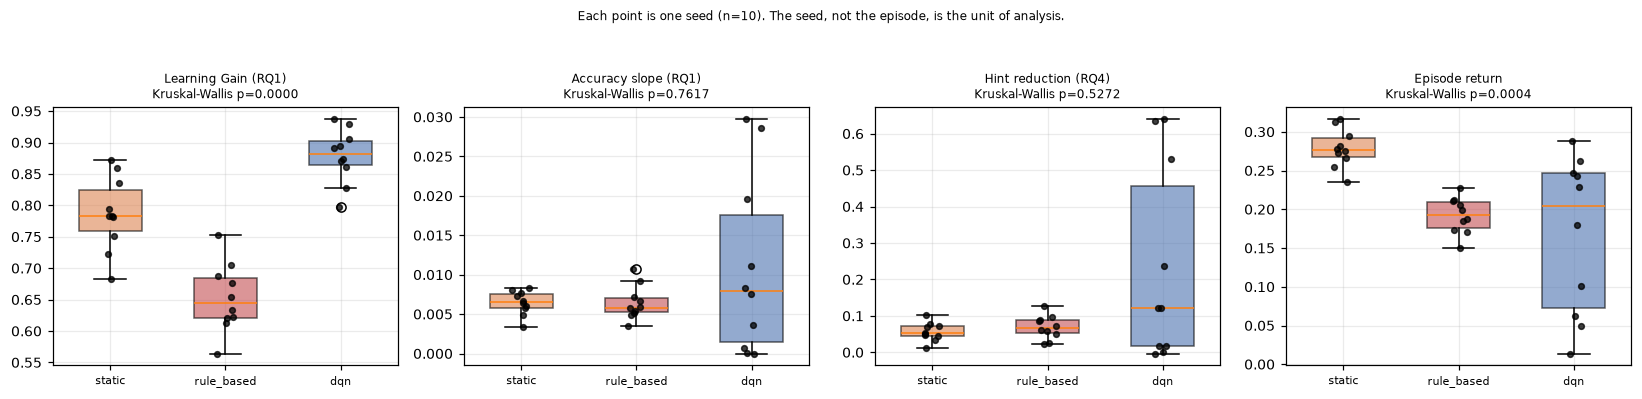

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
colours = {"static": ORANGE, "rule_based": RED, "dqn": BLUE}
panels = [("learning_gain", "Learning Gain (RQ1)"),
          ("accuracy_slope", "Accuracy slope (RQ1)"),
          ("hint_reduction", "Hint reduction (RQ4)"),
          ("return", "Episode return")]

for ax, (metric, title) in zip(axes, panels):
    data = [by_seed.loc[by_seed["condition"] == c, metric].to_numpy() for c in CONDITIONS]
    bp = ax.boxplot(data, tick_labels=CONDITIONS, patch_artist=True, widths=0.55)
    for patch, c in zip(bp["boxes"], CONDITIONS):
        patch.set_facecolor(colours[c]); patch.set_alpha(0.6)
    for i, d in enumerate(data, start=1):
        ax.scatter(np.full(len(d), i) + np.random.uniform(-0.08, 0.08, len(d)),
                   d, s=14, color="black", zorder=3, alpha=0.75)
    p = results[metric]["p_kruskal"]
    ax.set_title(f"{title}\nKruskal-Wallis p={p:.4f}", fontsize=8)
    ax.tick_params(axis="x", labelsize=7)

fig.suptitle("Each point is one seed (n=10). The seed, not the episode, is the unit of analysis.",
             fontsize=8, y=1.05)
fig.tight_layout()
fig.savefig(FIGURES / "fig_5_4_statistical_comparison.png", bbox_inches="tight")
plt.show()